In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation

from src.utils import configure_logger
from GNN.training.utils import to_scalar
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [10]:
model_type="gnn"
epochs = 40
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "log_sre"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"


model_hparams = {
    "gnn_hidden": 128,
    "gnn_heads": 8,
    "global_hidden": 128,
    "reg_hidden": 64,
    "num_layers": 3,
    "dropout_rate": 0.14466592901950354,
}

train_hparams = {
    "weight_decay": 0.0011100615729802686,
    "grad_clip": 18.68332578469687,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

In [11]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-18 15:17:52,428 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-18 15:17:52,429 - GNN.training.runners - INFO - Training configuration done.
2026-06-18 15:17:52,430 - GNN.training.runners - INFO - Collecting data paths...
2026-06-18 15:17:52,431 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-18 15:17:52,431 - GNN.training.runners - INFO - Data paths collected.
2026-06-18 15:17:52,431 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-18 15:19:34,452 - GNN.training.runners - INFO - Loaders and model built.
2026-06-18 15:19:34,453 - GNN.training.runners - INFO - Starting training...
2026-06-18 15:19:34,454 - GNN.training.train - INFO - Using device: cuda
2026-06-18 15:19:34,459 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/40:  54%|█████▎    | 108/201 [01:00<00:51,  1.80it/s, loss=0.1879, graphs=13952]

2026-06-18 15:20:34,637 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 109/201 | loss 0.187889 | elapsed 60.2s | graphs 13952


2026-06-18 15:21:24,930 - GNN.training.train - INFO - Training complete (110.5s) | running validation...


2026-06-18 15:21:37,203 - GNN.training.train - INFO - Losses | train 0.157813 | val 0.119823 | lr 9.86e-04 | time train=110.5s val=12.3s total=122.7s
2026-06-18 15:21:37,205 - GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-06-18 16:49:32,349 - GNN.training.train - INFO - [Heartbeat] Epoch 40 batch 96/201 | loss 0.111619 | elapsed 60.4s | graphs 12288


Epoch 40/40:  96%|█████████▌| 192/201 [02:00<00:05,  1.68it/s, loss=0.1119, graphs=24704]

2026-06-18 16:50:32,847 - GNN.training.train - INFO - [Heartbeat] Epoch 40 batch 193/201 | loss 0.111898 | elapsed 120.9s | graphs 24704


2026-06-18 16:50:38,230 - GNN.training.train - INFO - Training complete (126.3s) | running validation...


2026-06-18 16:50:52,359 - GNN.training.train - INFO - Losses | train 0.111676 | val 0.116636 | lr 1.23e-04 | time train=126.3s val=14.1s total=140.4s
2026-06-18 16:54:12,593 - GNN.training.runners - INFO - Training complete.
2026-06-18 16:54:12,660 - experiments.plotting - INFO - Saved training curve plot to outputs\figures\training_curves\training_curves_gnn_huber_random_2.png
2026-06-18 16:54:12,670 - GNN.training.runners - INFO - Saved model checkpoint to ..\notebooks\outputs\models\final\random_model_gnn_per_family_log_sre.pt
2026-06-18 16:54:12,731 - scripts.train_model - INFO - Final test loss: 0.108626
2026-06-18 16:54:12,733 - scripts.train_model - INFO - Test R2 score: 0.4380
2026-06-18 16:54:12,733 - scripts.train_model - INFO - Validation R2 score: 0.4411
2026-06-18 16:54:12,734 - scripts.train_model - INFO - Training R2 score: 0.4462


In [12]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = f"../notebooks/outputs/models/final/random_model_gnn_per_family_log_sre.pt"
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-18 16:58:18,394 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/outputs/models/final/random_model_gnn_per_family_log_sre.pt
2026-06-18 16:58:18,405 - scripts.predictions - INFO - Found 1 prediction files
Predicting (gnn): 100%|██████████| 7810/7810 [14:16<00:00,  9.12batch/s]
2026-06-18 17:13:11,900 - scripts.predictions - INFO - Saved 124950 predictions to outputs/predictions/family/gnn_predictions_random.csv


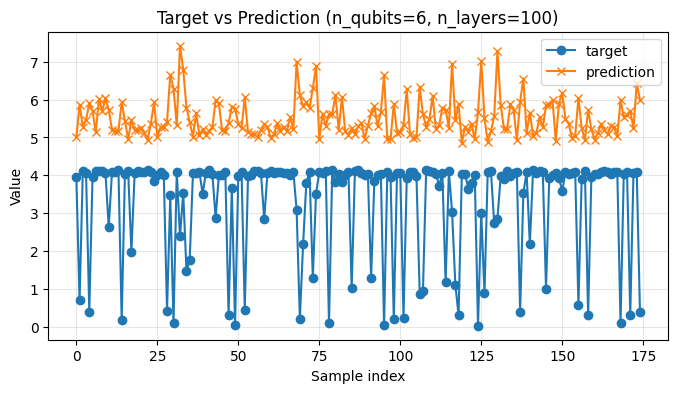

Pearson r = -0.4095


Text(0.5, 1.0, 'True vs Predicted SRE for Quansistor Family (GNN Model)')

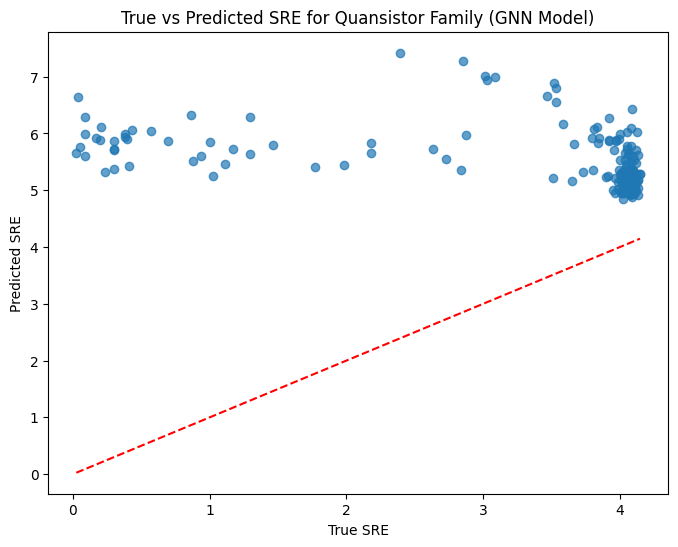

In [13]:
df = pd.read_csv(f"../outputs/predictions/family/gnn_predictions_random.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

nq=plot_qubits
nl=plot_layers
df["prediction"] = df["prediction"]
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target",
    col_y="prediction",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target"], df["prediction"], alpha=0.7)
plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")

### Optuna search

In [ ]:
study_name = f"optuna_search_{model_type}_{training_mode}_{family}_{target}_1"
storage_url = "sqlite:///optuna_studies.db"
n_trials = 15

optuna_search(
    model_type=model_type,
    training_mode=training_mode,
    family=family,
    data_dir=training_data_dir,
    target=target,
    study_name=study_name,
    storage_url=storage_url,
    n_trials=n_trials,
)

2026-06-15 20:01:43,708 - scripts.optuna_search - INFO - Starting Optuna hyperparameter search...
2026-06-15 20:01:43,718 - scripts.optuna_search - INFO - Found 1 dataset files for target=sre in data_dir=../outputs/data/datasets_SRE.
2026-06-15 20:03:12,513 - scripts.optuna_search - INFO - Prepared datasets with loader_kind=gnn. Starting Optuna study with name='optuna_search_gnn_per_family_random_sre_1' and storage='sqlite:///optuna_studies.db'...
[I 2026-06-15 20:03:12,608] A new study created in RDB with name: optuna_search_gnn_per_family_random_sre_1
2026-06-15 20:03:12,612 - scripts.optuna_search - INFO - Running Optuna optimization for 15 trials...
2026-06-15 20:03:12,745 - GNN.training.train - INFO - Using device: cuda
2026-06-15 20:03:19,287 - GNN.training.train - INFO - -------- EPOCH 001 --------
2026-06-15 20:04:19,517 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 98/201 | loss 0.221011 | elapsed 60.2s | graphs 12544
2026-06-15 20:05:19,663 - GNN.training.train - IN